### Схема работы Сиамской нейронной сети

<img src="/home/cyberpsychoz/NSU_studying-IIR/2_course/1_sem/PAC/images/Labs/II/scheme.png" alt="scheme" height=40% width=40%>

### Примеры использования

**Распознавание лиц**: При наличии двух отдельных изображений, содержащих лицо, позволяет определить один и тот же человек находится на обеих фотографиях или нет.

**Проверка подписи**: При наличии двух подписей определяет, является ли одна из них подделкой или нет.

**Идентификация таблеток**, отпускаемых по рецепту: При наличии двух таблеток, отпускаемых по рецепту, определияет, являются ли они одним и тем же лекарством или разными лекарствами.

и т.д.

### Популярные функции потерь при обучении сиамских сетей включают:

    
    - Binary cross-entropy
    - Triplet loss
    - Contrastive loss

<img src="/home/cyberpsychoz/NSU_studying-IIR/2_course/1_sem/PAC/images/Labs/II/i.jpeg" alt="scheme" height=60% width=70%>

### Binary cross-entropy loss

При использовании бинарной кросс-энтропии (BCELoss) в качестве лосс-функции, необходимо посчитать евклидово расстояние между двумя векторами, передать полученное значение в функцию активации sigmoid и сравнить с target-ом (1/0)

<img src="/home/cyberpsychoz/NSU_studying-IIR/2_course/1_sem/PAC/images/Labs/II/euclidean_distance.png" alt="scheme" height=40% width=40%>

### Contrastive loss function

При использовании Contrastive loss-функции, её необходимо реализовать самому

<img src="/home/cyberpsychoz/NSU_studying-IIR/2_course/1_sem/PAC/images/Labs/II/contrastive_loss.png" alt="scheme" height=40% width=40%>

**Y** : Метки из набора данных. Значение 1 указывает на то, что два изображения в паре относятся к одному классу, в то время как значение 0 указывает на то, что изображения принадлежат к двум разным классам.

**Dw**: расстояния между парами векторов (закодированных изображений).

**m**: (margin) маржа/запас/резерв, используемый для функции контрастных потерь (обычно это значение устанавливается равным 1 ).

Для расчёта расстояния между векторами (Dw) можно использовать  torch.nn.functional.pairwise_distance()

#### Dataset

https://www.cl.cam.ac.uk/research/dtg/attarchive/facedatabase.html

https://www.kaggle.com/datasets/kasikrit/att-database-of-faces

### Результаты

I) - t-SNE

II) - inference

результаты работы сети должны выглядеть примерно так (только с лицами):

<img src="/home/cyberpsychoz/NSU_studying-IIR/2_course/1_sem/PAC/images/Labs/II/results.png" alt="results MNIST" height=30% width=30%>

2) Написать "сиамскую" нейросеть
3*) Используя BCELoss обучить нейронку кодировать изображения одного человека (одного класса) похожим образом
4) С помощью t-SNE визуализировать результаты работы (использовать тестовый датасет)
5) Визуализировать результаты работы (inference) в виде - пара изображений + distance
6) Вместо BCELoss использовать "Contrastive loss function", сравнить результаты


In [1]:
import torch 
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import transforms
from torchvision.datasets import ImageFolder
from torchvision import models
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.manifold import TSNE
import numpy as np


import os
import random


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
class SiamNet(torch.nn.Module):
    def __init__(self, emb_dim = 128):
        super(SiamNet, self).__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, emb_dim)
    
    def _forward_once(self, x):
        out = self.backbone(x)

        out = F.normalize(out, p=2, dim=1)
        return out

    def forward(self, image1, image2):
        emb1 = self._forward_once(image1)
        emb2 = self._forward_once(image2)
        return emb1, emb2  

In [3]:
class LicoDataset(Dataset):
    def __init__(self, image_folder, transform = None):
        self.image_folder = image_folder
        self.transform = transform
        self.classes = os.listdir(image_folder)
        self.class_to_paths = {
            cls_name: [os.path.join(image_folder, cls_name, img) 
                       for img in os.listdir(os.path.join(image_folder, cls_name))]
            for cls_name in self.classes
        }

    def __getitem__(self, index):
        make_same_class = random.random() > 0.5
        
        if make_same_class:
            cls = random.choice(self.classes)
            img1_path, img2_path = random.sample(self.class_to_paths[cls], 2)
            label = 1.0
        else:
            cls1, cls2 = random.sample(self.classes, 2)
            img1_path = random.choice(self.class_to_paths[cls1])
            img2_path = random.choice(self.class_to_paths[cls2])
            label = 0.0
            
        img1 = Image.open(img1_path).convert("RGB")
        img2 = Image.open(img2_path).convert("RGB")
        
        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)
            
        return img1, img2, torch.tensor([label], dtype=torch.float32)
    
    def __len__(self):
        return len(self.classes) * 10


In [ ]:
def train_siamnet_bce(model, dataloader, epochs = 5):
    optimizer = optim.Adam(model.parameters(), lr = 1e-4)
    criterion = nn.BCELoss()
    model.to(device)
    model.train()

    for epoch in range(epochs):
        epoch_loss = 0.0
        for img1, img2, labels in dataloader:
            img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)

            optimizer.zero_grad()
            emb1, emb2 = model(img1, img2)
            distance = F.pairwise_distance(emb1, emb2, keepdim=True)

            preds = torch.exp(-distance)
            
            labels = labels.view(-1, 1)
            
            loss = criterion(preds, labels)
            
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(dataloader):.4f}")

In [5]:
def visualize_tsne(model, dataloader):

    model.eval()
    embeddings = []
    labels = []
    
    with torch.no_grad():
        for img, label in dataloader:
            img = img.to(device)

            emb = model._forward_once(img)
            embeddings.append(emb.cpu().numpy())
            labels.append(label.numpy())
            
    embeddings = np.concatenate(embeddings)
    labels = np.concatenate(labels)

    tsne = TSNE(n_components=2, random_state=42)
    embeddings_2d = tsne.fit_transform(embeddings)

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=labels, cmap='tab20')
    plt.legend(*scatter.legend_elements(), title="Classes")
    plt.title("t-SNE Visualization")
    plt.show()

In [6]:
def visualize_inference(model, dataset, num_pairs=5):

    model.eval()
    fig, axes = plt.subplots(num_pairs, 2, figsize=(6, num_pairs * 3))

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    with torch.no_grad():
        for i in range(num_pairs):
            img1, img2, label = dataset[i] 
            
            emb1, emb2 = model(img1.unsqueeze(0).to(device), img2.unsqueeze(0).to(device))
            dist = F.pairwise_distance(emb1, emb2).item()
            
            pic1 = img1.permute(1, 2, 0).numpy()
            pic1 = std * pic1 + mean
            
            pic2 = img2.permute(1, 2, 0).numpy()
            pic2 = std * pic2 + mean
            
            axes[i, 0].imshow(np.clip(pic1, 0, 1))
            axes[i, 0].axis('off')
            axes[i, 0].set_title(f"Label: {int(label.item())}")
            
            axes[i, 1].imshow(np.clip(pic2, 0, 1))
            axes[i, 1].axis('off')
            axes[i, 1].set_title(f"Dist: {dist:.4f}")
            
    plt.tight_layout()
    plt.show()

In [7]:
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=2.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        euclidean_distance = F.pairwise_distance(output1, output2, keepdim=True)
        
        label = label.view(-1, 1)
        
        loss_contrastive = torch.mean((label) * torch.pow(euclidean_distance, 2) +
                                      (1 - label) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2))
        return loss_contrastive

def train_siamnet_contrastive(model, dataloader, epochs=5):
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = ContrastiveLoss(margin=2.0)
    model.to(device)
    model.train()

    for epoch in range(epochs):
        epoch_loss = 0.0
        for img1, img2, labels in dataloader:
            img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)
            
            optimizer.zero_grad()
            emb1, emb2 = model(img1, img2)
            
            loss = criterion(emb1, emb2, labels)
            
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            
        print(f"Epoch {epoch+1}/{epochs}, Contrastive Loss: {epoch_loss/len(dataloader):.4f}")

Epoch 1/7, Loss: 0.5371
Epoch 2/7, Loss: 0.4107
Epoch 3/7, Loss: 0.3342
Epoch 4/7, Loss: 0.3380
Epoch 5/7, Loss: 0.3019
Epoch 6/7, Loss: 0.2861
Epoch 7/7, Loss: 0.2681


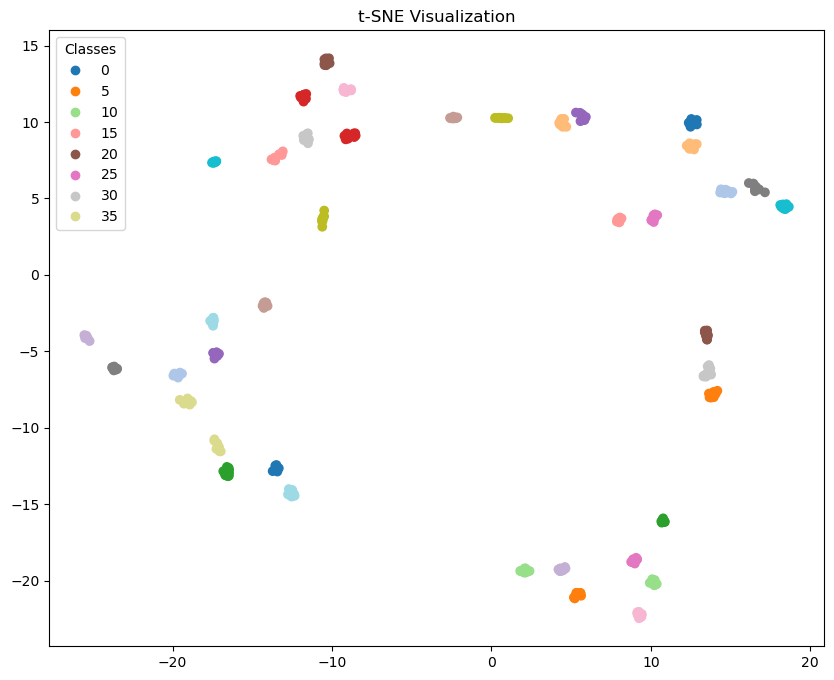

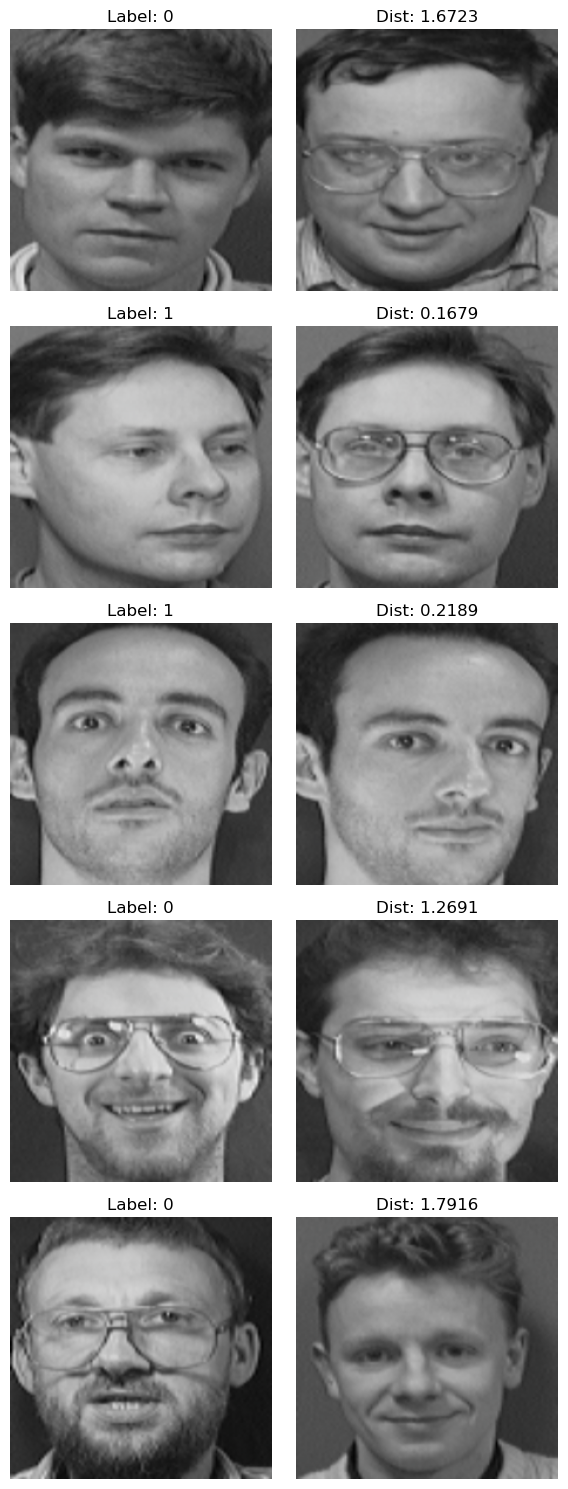

Epoch 1/7, Contrastive Loss: 0.6677
Epoch 2/7, Contrastive Loss: 0.4384
Epoch 3/7, Contrastive Loss: 0.3278
Epoch 4/7, Contrastive Loss: 0.3136
Epoch 5/7, Contrastive Loss: 0.3082
Epoch 6/7, Contrastive Loss: 0.2587
Epoch 7/7, Contrastive Loss: 0.2462


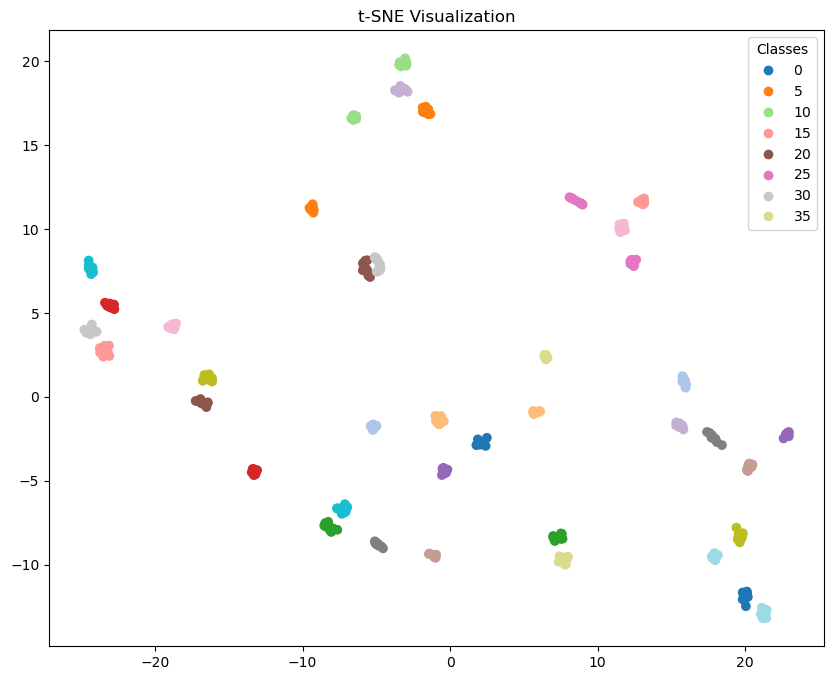

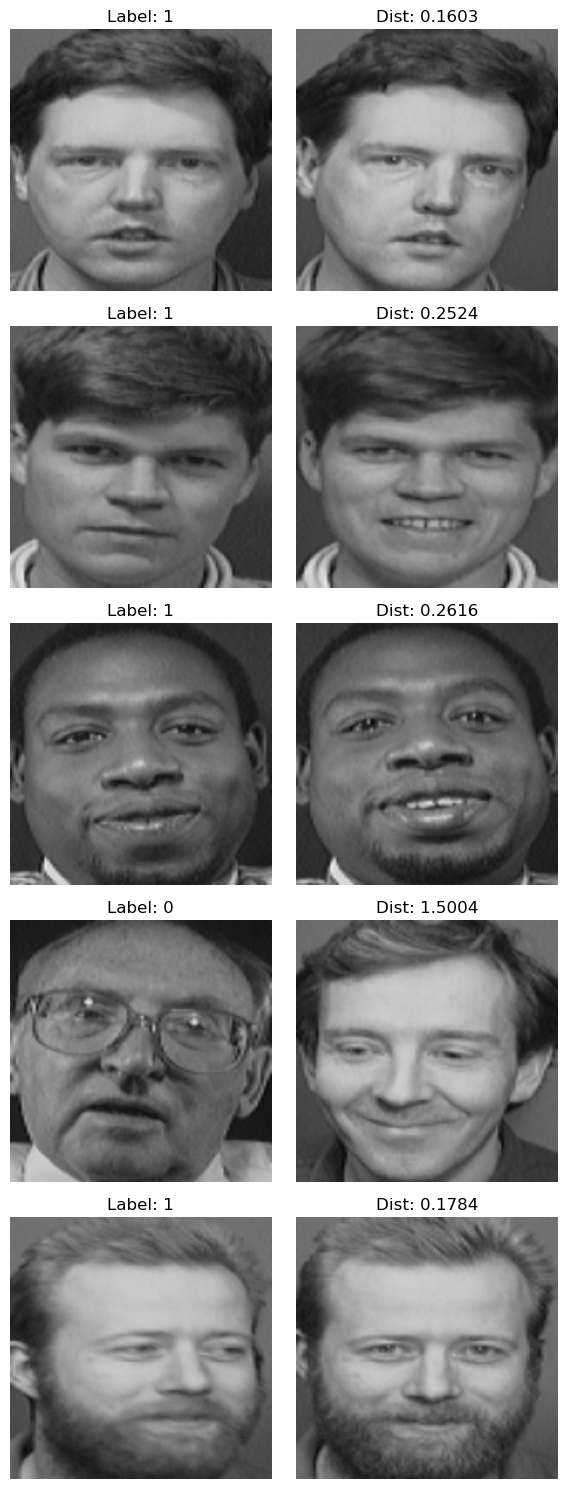

In [8]:
transform = transforms.Compose([
    transforms.Grayscale(3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

data_path = 'images'

train_dataset = LicoDataset(data_path, transform)
train_loader = DataLoader(train_dataset, 32, num_workers= 4, shuffle= True)

test_dataset = ImageFolder(data_path, transform= transform)
test_loader_single = DataLoader(test_dataset, 32, shuffle= False, num_workers=4)

model = SiamNet().to(device)

train_siamnet_bce(model, train_loader, epochs= 7)

visualize_tsne(model, test_loader_single)

visualize_inference(model, train_dataset)

model_2 = SiamNet().to(device)

train_siamnet_contrastive(model_2, train_loader, epochs= 7)

visualize_tsne(model_2, test_loader_single)

visualize_inference(model_2, train_dataset)